**Лінійна фільтрація**


(-0.5, 511.5, 340.5, -0.5)

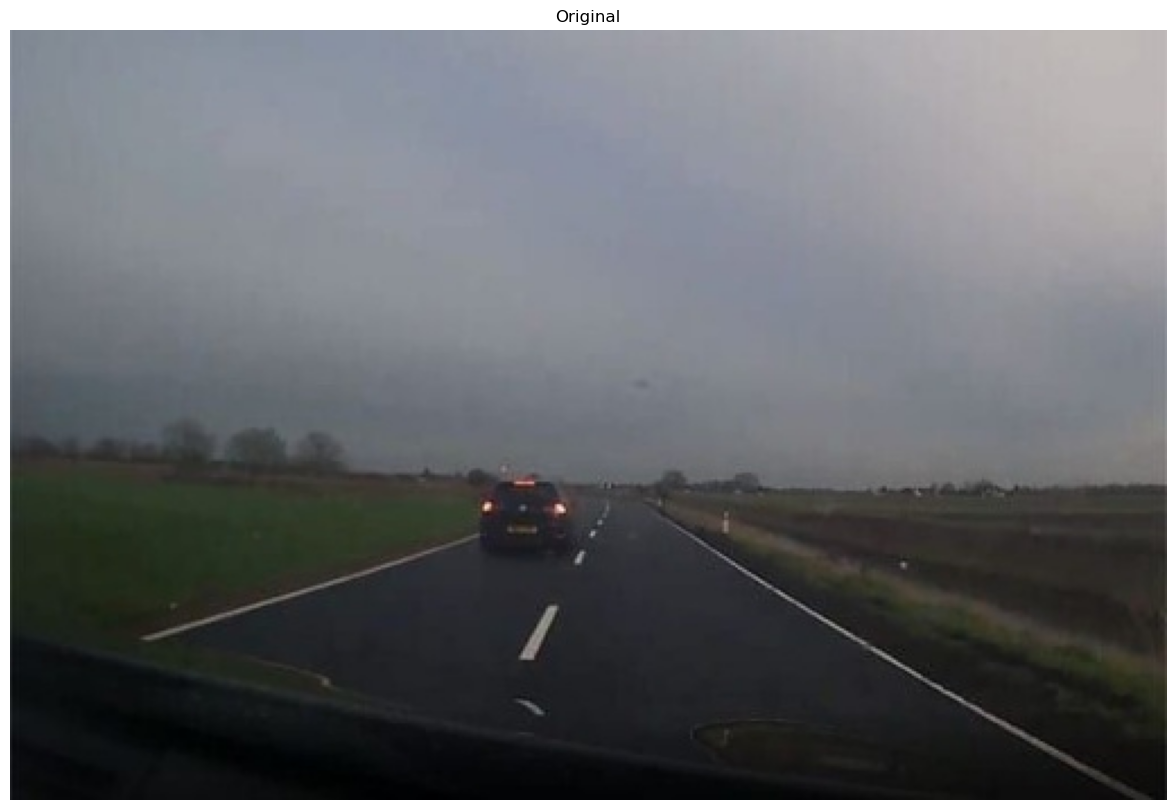

In [203]:
# Імпорт та завантаження зображення
import cv2
import math
import numpy as np
from matplotlib import pyplot as plt

plt.rcParams['figure.figsize'] = [15, 10]

img = cv2.imread("C:/Users/User/Downloads/dashcam.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title("Original")
plt.axis(False)

*Перетворення в grayscale + Canny*

In [206]:
# grayscale
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# згладжування (прибирає шум)
blur = cv2.GaussianBlur(gray, (5,5), 0)

(<Axes: title={'center': 'Edges (Canny)'}>,
 Text(0.5, 1.0, 'Edges (Canny)'))

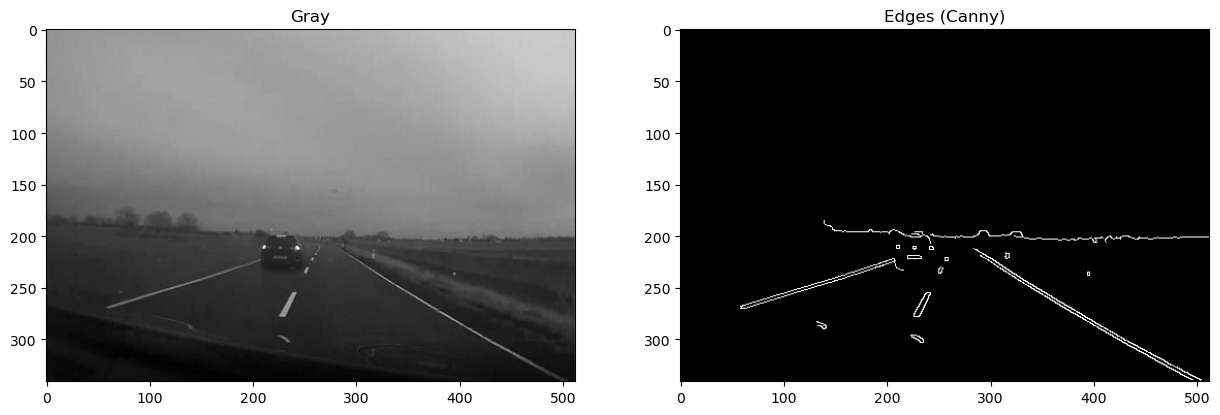

In [208]:
edges = cv2.Canny(blur, 30, 120)

plt.subplot(121), plt.imshow(gray, cmap='gray'), plt.title('Gray')
plt.subplot(122), plt.imshow(edges, cmap='gray'), plt.title('Edges (Canny)')

*Перетворення Sobel Edge Detector*

(-0.5, 511.5, 340.5, -0.5)

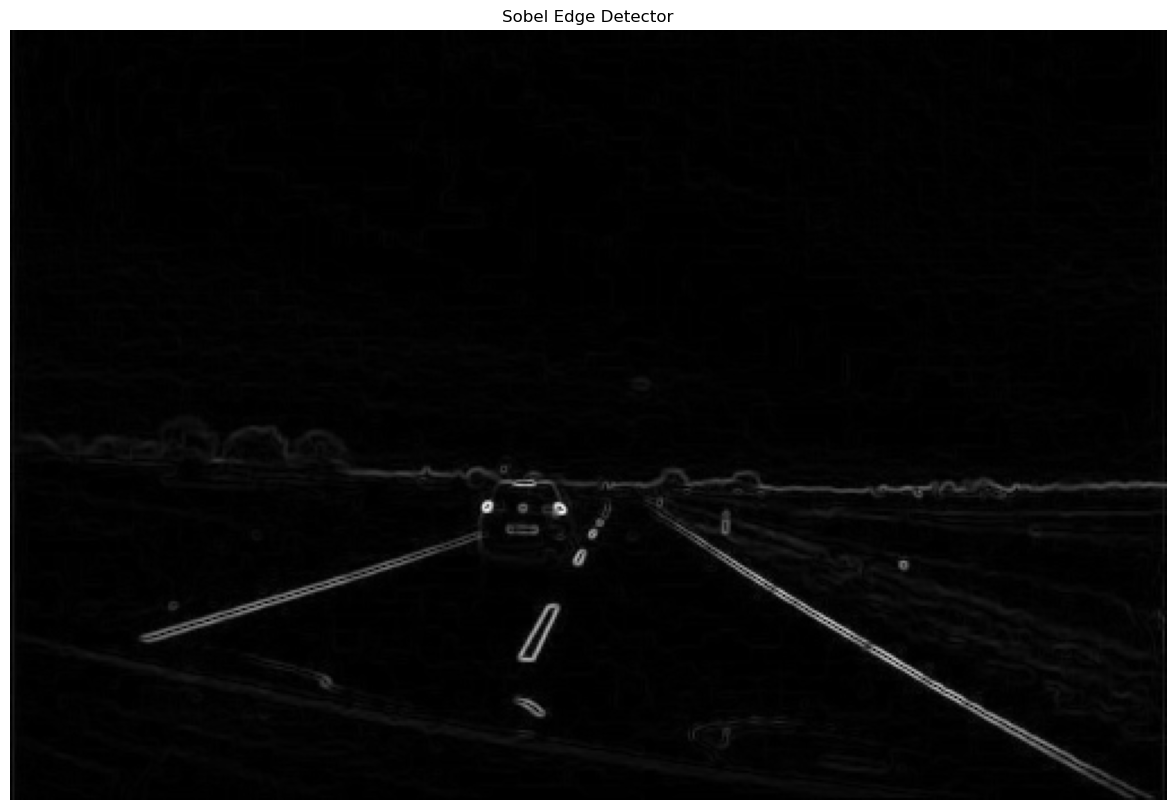

In [211]:
# Sobel Edge Detector

# обчислення градієнтів по X та Y
grad_x = cv2.Sobel(gray, ddepth=cv2.CV_64F, dx=1, dy=0)
grad_y = cv2.Sobel(gray, ddepth=cv2.CV_64F, dx=0, dy=1)

# обчислення модуля градієнта
sobel = np.sqrt(grad_x**2 + grad_y**2)

# нормалізація до діапазону [0,1]
sobel = sobel / np.max(sobel)

# вивід результату
plt.imshow(sobel, cmap='gray')
plt.title("Sobel Edge Detector")
plt.axis(False)

(-0.5, 511.5, 340.5, -0.5)

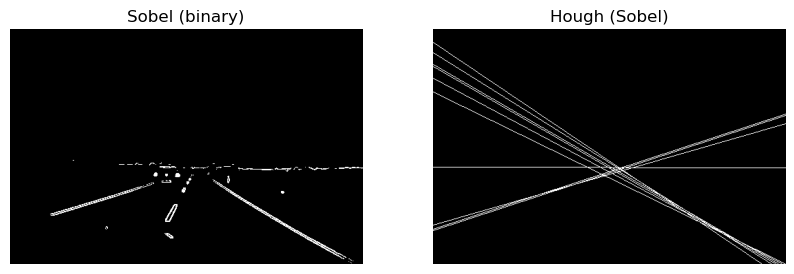

In [225]:
# перетворення Sobel в бінарне зображення для Hough
sobel_bin = (sobel > 0.2).astype(np.uint8) * 255

# застосування Hough Transform
lines = cv2.HoughLines(sobel_bin, rho=1, theta=2*np.pi/180, threshold=85)

# створюємо порожнє зображення
hough_sobel = np.zeros_like(sobel_bin)

# малюємо знайдені лінії
for i in range(len(lines)):
    rho = lines[i][0][0]
    theta = lines[i][0][1]

    a = math.cos(theta)
    b = math.sin(theta)

    x0 = a * rho
    y0 = b * rho

    pt1 = (int(x0 + 1000*(-b)), int(y0 + 1000*(a)))
    pt2 = (int(x0 - 1000*(-b)), int(y0 - 1000*(a)))

    cv2.line(hough_sobel, pt1, pt2, 255, 1)

# вивід результату
plt.figure(figsize=(10,5))

plt.subplot(121)
plt.imshow(sobel_bin, cmap='gray')
plt.title("Sobel (binary)")
plt.axis(False)

plt.subplot(122)
plt.imshow(hough_sobel, cmap='gray')
plt.title("Hough (Sobel)")
plt.axis(False)

*Перетворення Хафа для Canny*

In [227]:
lines = cv2.HoughLines(edges, 1, np.deg2rad(2), 80)

lines = lines[:, 0, :]

(-0.5, 511.5, 340.5, -0.5)

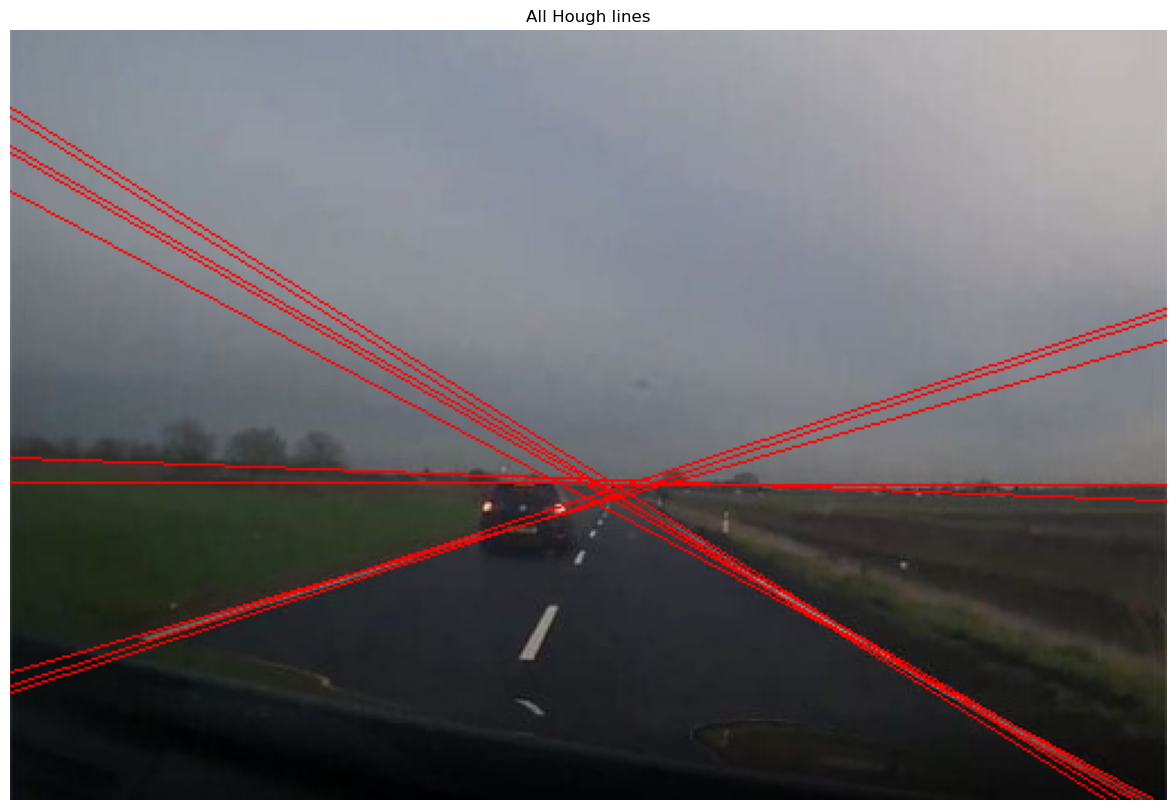

In [229]:
result = np.copy(img)

for rho, theta in lines:
    a = np.cos(theta)
    b = np.sin(theta)

    x0 = a * rho
    y0 = b * rho

    pt1 = (int(x0 + 1000*(-b)), int(y0 + 1000*(a)))
    pt2 = (int(x0 - 1000*(-b)), int(y0 - 1000*(a)))

    cv2.line(result, pt1, pt2, (255,0,0), 1)

plt.imshow(result)
plt.title("All Hough lines")
plt.axis(False)

*Фільтрація горизонтальних ліній*

In [248]:
filtered_lines = []

for rho, theta in lines:
    theta_deg = np.rad2deg(theta)

    # залишаємо тільки "похилі" лінії дороги
    if 10 < theta_deg < 160 and not (80 < theta_deg < 90):
        filtered_lines.append((rho, theta))

(-0.5, 511.5, 340.5, -0.5)

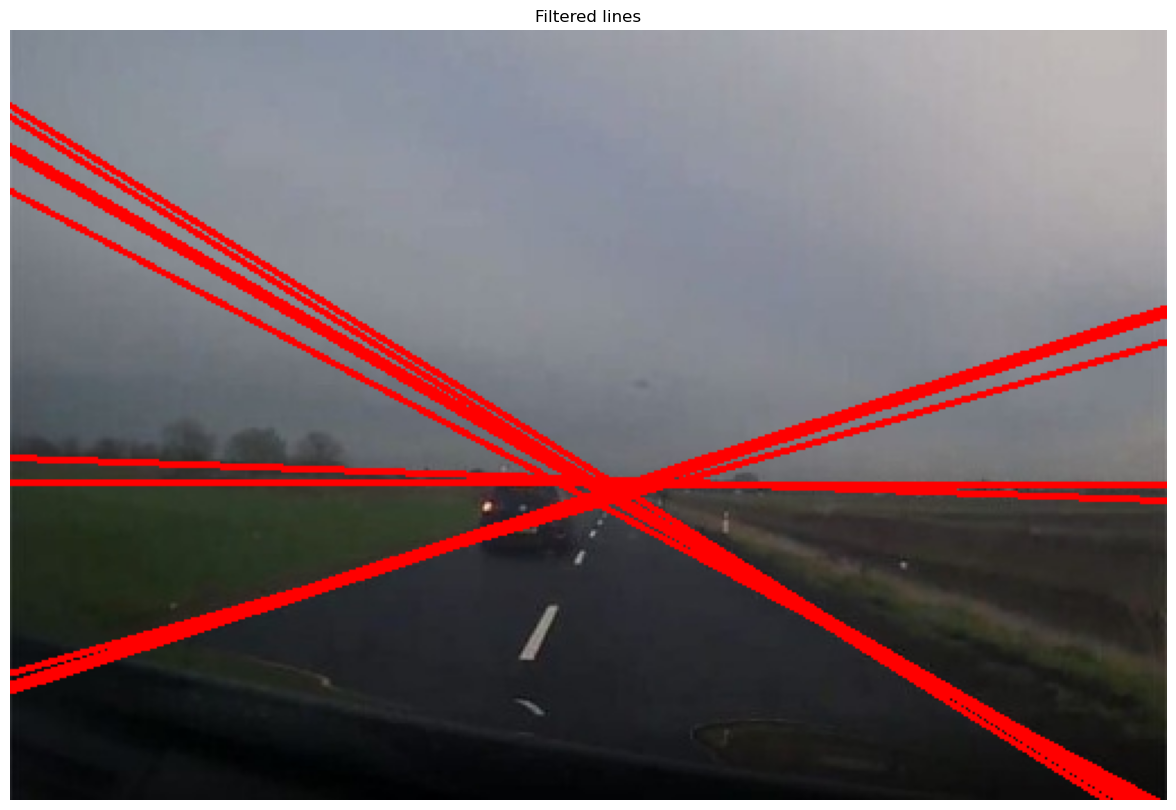

In [250]:
# Відображення після фільтрації
result = np.copy(img)

for rho, theta in filtered_lines:
    a = np.cos(theta)
    b = np.sin(theta)

    x0 = a * rho
    y0 = b * rho

    pt1 = (int(x0 + 1000*(-b)), int(y0 + 1000*(a)))
    pt2 = (int(x0 - 1000*(-b)), int(y0 - 1000*(a)))

    cv2.line(result, pt1, pt2, (255,0,0), 2)

plt.imshow(result)
plt.title("Filtered lines")
plt.axis(False)

*K-means кластеризація*

In [252]:
filtered_lines = np.array(filtered_lines)

In [260]:
from sklearn.cluster import KMeans

# переводимо в numpy
filtered_lines_np = np.array(filtered_lines)

kmeans = KMeans(n_clusters=3, random_state=0).fit(filtered_lines_np)

centers = kmeans.cluster_centers_

D:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


(-0.5, 511.5, 340.5, -0.5)

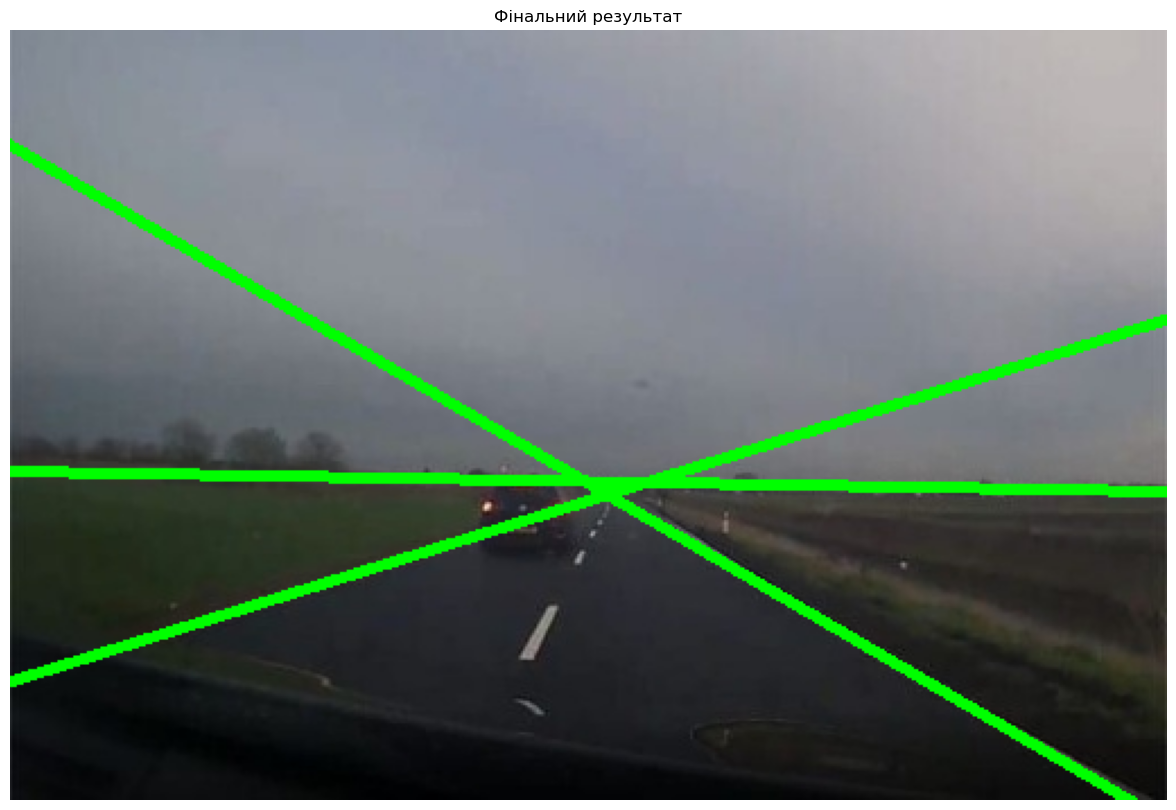

In [262]:
result = np.copy(img)

for rho, theta in centers:
    a = np.cos(theta)
    b = np.sin(theta)

    x0 = a * rho
    y0 = b * rho

    pt1 = (int(x0 + 1000*(-b)), int(y0 + 1000*(a)))
    pt2 = (int(x0 - 1000*(-b)), int(y0 - 1000*(a)))

    cv2.line(result, pt1, pt2, (0,255,0), 3)

plt.imshow(result)
plt.title("Фінальний результат")
plt.axis(False)

**Висновок**

Фінальний результат дозволяє знайти основні лінії дороги, хоча можуть бути незначні похибки та шум.
Роздільна здатність перетворення Хафа впливає на точність: менші значення дають точніші лінії, але більше шуму, більші — менш точні, але стабільніші.
Правильний підбір параметрів є важливим для отримання якісного результату. Поріг акумулятора визначає кількість знайдених ліній. Якщо малий поріг дає багато зайвих ліній, великий — може пропустити потрібні.

*Порівняння Sobel та Canny*

Canny детектор дає більш чіткі та тонкі межі, що призводить до кращого результату при застосуванні перетворення Хафа.
Sobel детектор є простішим, але більш чутливим до шуму, тому результати Hough містять більше зайвих ліній.
Отже, для задачі детекції дорожніх ліній більш ефективним є використання Canny.

Для експеременту зроблю ще для іншого зображення

In [279]:
plt.rcParams['figure.figsize'] = [15, 10]

(<Axes: >, <matplotlib.image.AxesImage at 0x19d3e6e27b0>)

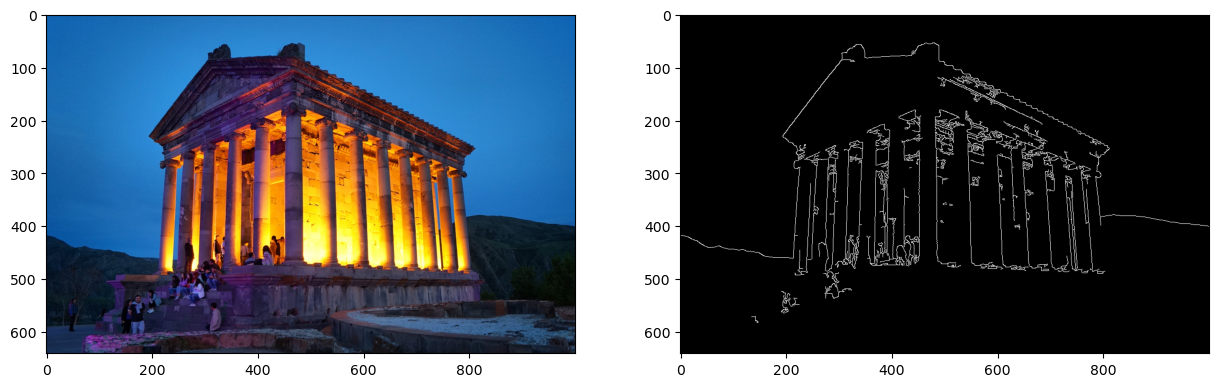

In [267]:
img = cv2.imread('C:/Users/User/Downloads/100.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
edges = cv2.Canny(gray, threshold1=100, threshold2=550)

plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(edges, cmap='gray')

(<Axes: >, <matplotlib.image.AxesImage at 0x19d3e6fd070>)

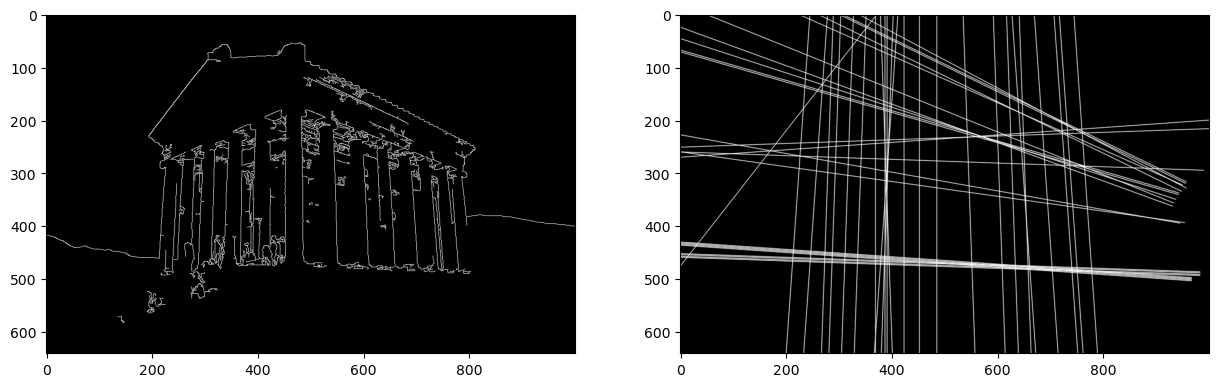

In [269]:
lines = cv2.HoughLines(edges, rho=1, theta=2*np.pi/180, threshold=85)
hough = np.zeros_like(edges)
    
for i in range(0, len(lines)):
    rho = lines[i][0][0]
    theta = lines[i][0][1]
    a = math.cos(theta)
    b = math.sin(theta)
    x0 = a * rho
    y0 = b * rho
    pt1 = (int(x0 + 1000*(-b)), int(y0 + 1000*(a)))
    pt2 = (int(x0 - 1000*(-b)), int(y0 - 1000*(a)))
    cv2.line(hough, pt1, pt2, 255, 1, cv2.LINE_AA)

plt.subplot(121), plt.imshow(edges, cmap='gray')
plt.subplot(122), plt.imshow(hough, cmap='gray')